In [1]:
# =========================
# Imports
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns




In [2]:
# =========================
# Device
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# =========================
# Dataset Path
# =========================

data_dir = "Chessman-image-dataset/Chess"



Device: cuda


In [3]:
# =========================
# Transforms
# =========================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#hint from Hanan: برای پر کردن کد به عملیات ترنسفرم داده ی آموزش نگاه کنید. کدوم عملیات فقط روی داده ی آموزشی انجام میشه و کدوم روی همه ی داده ها؟


Classes: ['Bishop', 'King', 'Knight', 'Pawn', 'Queen', 'Rook']
Number of classes: 6
Total images: 552
Train images: 386
Validation images: 82
Test images: 84


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1975338].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..1.9428324].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5014129..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.146

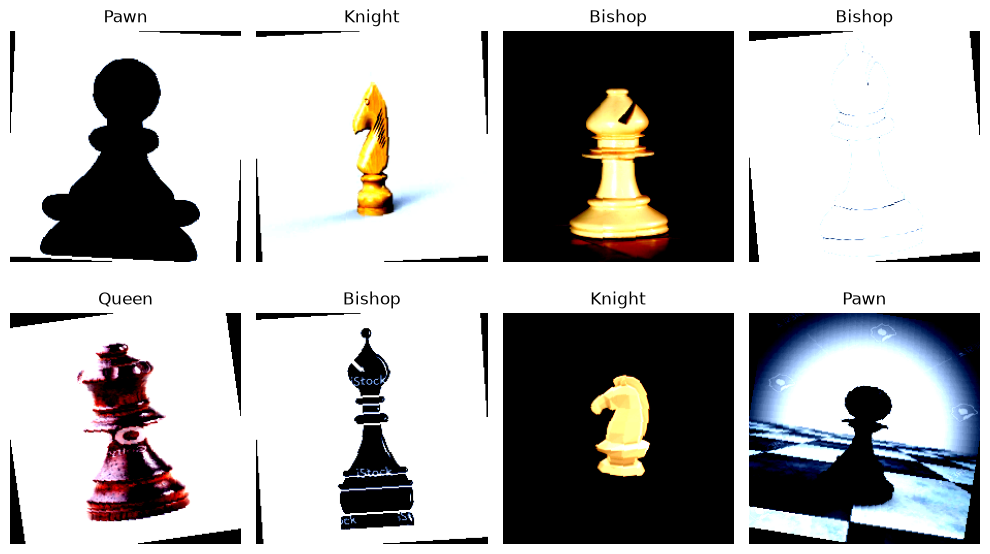

In [4]:
# =========================
# Load Dataset
# =========================

base_dataset = datasets.ImageFolder(root=data_dir)

train_full = datasets.ImageFolder(
    root= data_dir,
    transform=train_transform
)

eval_full = datasets.ImageFolder(
    root=data_dir,
    transform= eval_transform
)

class_names = base_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(base_dataset))


# =========================
# Train / Validation / Test Split
# =========================

train_size = int(0.7 * len(base_dataset))
val_size = int(0.15 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size

#hint from Hanan: به عملیات دقت کنید. ما بخشی از داده رو برای آموزش و اعتبار سنجی برای آموزشی برداشتیم. پس اون چیزی که باقی میمونه رو برای تست برمیداریم.

generator = torch.Generator().manual_seed(42)

train_indices, val_indices, test_indices = random_split(
    range(len(base_dataset)),
    [train_size, val_size, test_size],
    generator=generator
)

train_dataset = Subset(train_full, train_indices.indices)
val_dataset = Subset(eval_full, val_indices.indices)
test_dataset = Subset(eval_full, test_indices.indices)
    
#hint from Hanan: این قسمت رو عجله نکنید و دقت کنید. ما دو مدل عملیات ترنسفرم تعریف کردیم. یکی برای داده ی آموزش و یکی برای ولیدیشن و تست

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))


# =========================
# DataLoaders
# =========================

batch_size = 32
# train - validation - test----------------
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# =========================
# Show Sample Images
# =========================

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(8):
    image = images[i].permute(1, 2, 0)
    label = labels[i].item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [10]:
# =========================
# Model
# =========================



from torchvision import models

model = models.resnet18(pretrained=True)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print(model)

# =========================
# Loss and Optimizer
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001 # learning rate
)

#hint from Hanan: ما اینجا به لرنینگ ریت نیاز داریم. روی عدد لرنینگ ریت سختگیری نمیکنیم. ولی عددای مختلف رو امتحان کنید. 

# =========================
# Training Loop
# =========================

num_epochs = 30 # try different numbers here

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # ---- Training ----
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
        
    #hint from Hanan = میخوایم مقدار دقت و لاس رو حساب کنیم. باید فرمول ها رو تکمیل کنید.

    # ---- Validation ----
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss =val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

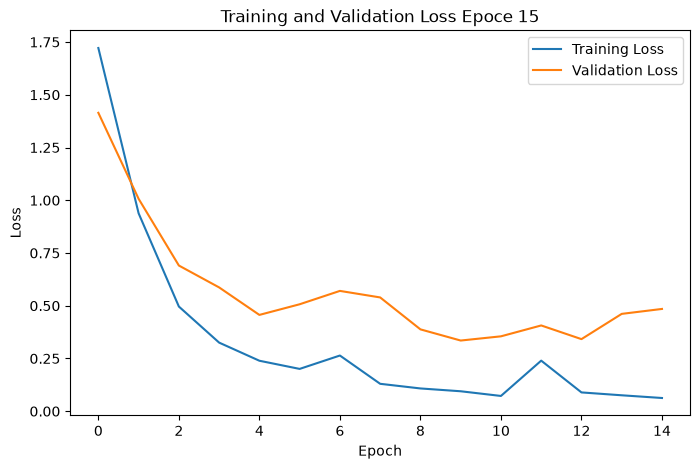

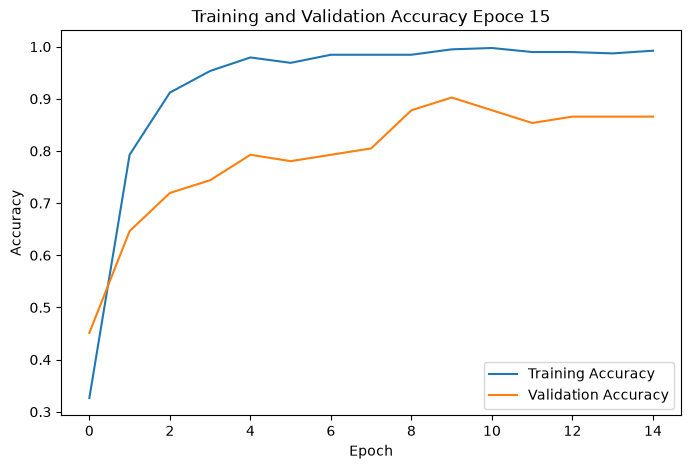

In [9]:
# =========================
# Plot Loss Curves
# =========================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Epoce 15")
plt.legend()
plt.show()


# =========================
# Plot Accuracy Curves
# =========================

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Epoce 15")
plt.legend()
plt.show()

# just run this cell :D

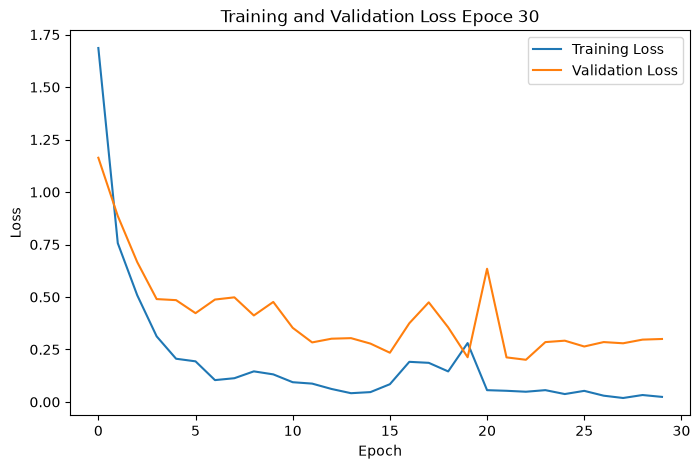

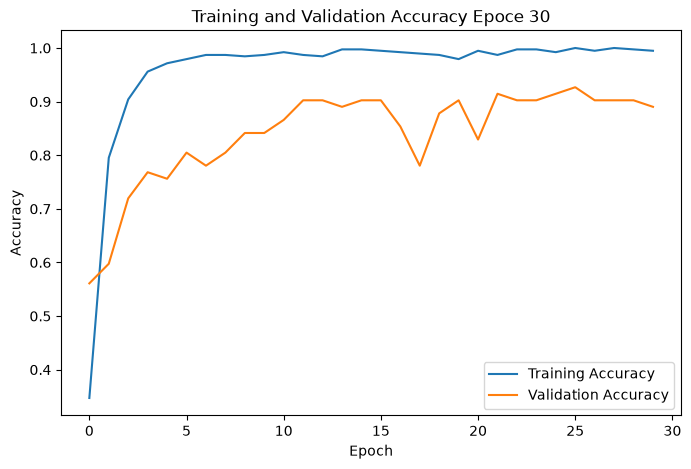

In [11]:
# =========================
# Plot Loss Curves
# =========================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Epoce 30")
plt.legend()
plt.show()


# =========================
# Plot Accuracy Curves
# =========================

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Epoce 30")
plt.legend()
plt.show()

# just run this cell :D

Test Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

      Bishop       1.00      1.00      1.00         9
        King       0.90      0.90      0.90        10
      Knight       1.00      1.00      1.00        17
        Pawn       1.00      0.92      0.96        25
       Queen       0.85      0.92      0.88        12
        Rook       0.92      1.00      0.96        11

    accuracy                           0.95        84
   macro avg       0.94      0.96      0.95        84
weighted avg       0.96      0.95      0.95        84



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.352941..2.3785625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4842881..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping inpu

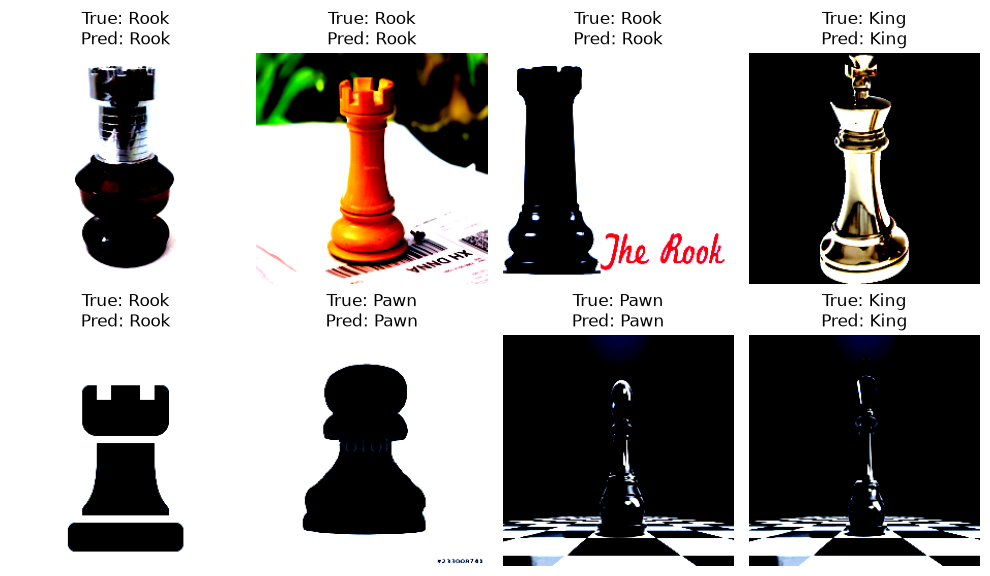

In [12]:
# =========================
# Final Test Evaluation
# =========================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# =========================
# Test Accuracy
# =========================

correct = 0

for pred, label in zip(all_preds, all_labels):
    if pred == label:
        correct += 1

test_accuracy = correct / len(all_labels)

print("Test Accuracy:", test_accuracy)


# =========================
# Classification Report
# =========================

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))




# =========================
# Show Some Test Predictions
# =========================

images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(10, 6))

for i in range(8):
    image = images[i].permute(1, 2, 0)

    true_label = class_names[labels[i].item()]
    pred_label = class_names[predicted[i].item()]

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()